In [3]:
#Import the Tensorflow library, tf is  an alias or a short name  to make it easier  when  writing codes

import tensorflow as tf

#Import numpy

import numpy as np

#Import datasets, layers, models from keras, which is a high-level API inside TensorFlow

from tensorflow.keras import datasets, layers, models

import matplotlib.pyplot as plt

In [2]:
pip install matplotlib

     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.8 kB ? eta -:--:--
     -------------- ----------------------- 20.5/52.8 kB 217.9 kB/s eta 0:00:01
     ---------------------- --------------- 30.7/52.8 kB 217.9 kB/s eta 0:00:01
     ------------------------------------ - 51.2/52.8 kB 262.6 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 226.6 kB/s eta 0:00:00
     ---------------------------------------- 0.0/119.8 kB ? eta -:--:--
     ------------ ------------------------ 41.0/119.8 kB 991.0 kB/s eta 0:00:01
     -------------------- ------------------ 61.4/119.8 kB 1.1 MB/s eta 0:00:01
     --------------------------------- -- 112.6/119.8 kB 819.2 kB/s eta 0:00:01
     ------------------------------------ 119.8/119.8 kB 702.2 kB/s eta 0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
    --------------------------------------- 0.2/8.1 MB 4.5 MB/s eta 0:00:


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Load the dataset

mnist_digits = datasets.mnist #Accesses the MNIST dataset from Keras

(train_digits, train_labels), (test_digits, test_labels) = mnist_digits.load_data() #loads the dataset

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [5]:
# Explore the data

print(train_digits.shape) #Display the shape of the training digits

print(train_labels.shape) #Display the shape of the training labels

print(train_labels) #Display the values of the training labels

(60000, 28, 28)
(60000,)
[5 0 4 ... 5 6 8]


In [6]:
print(train_digits.shape)

(60000, 28, 28)


In [7]:
print(train_labels.shape)

(60000,)


In [8]:
print(test_digits.shape)

(10000, 28, 28)


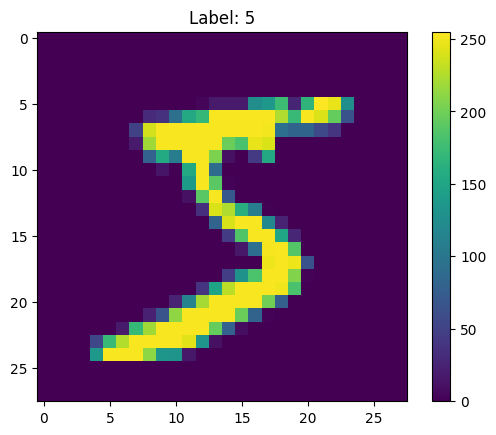

In [9]:
plt.figure()

plt.imshow(train_digits[0]) # Display the first image in the plot area

plt.colorbar()

plt.title(f"Label: {train_labels[0]}") # Displays the label of the first image

plt.grid(False)

plt.show() # Render and displaysthe plot window.

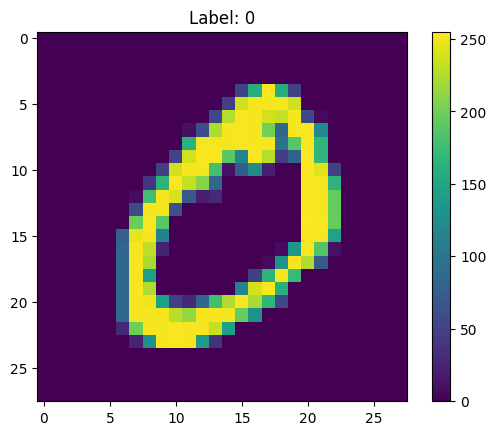

In [10]:
plt.figure()

plt.imshow(train_digits[1]) # Display the first image in the plot area

plt.colorbar()

plt.title(f"Label: {train_labels[1]}") # Displays the label of the first image

plt.grid(False)

plt.show() # Render and displaysthe plot window.

In [11]:
# Preprocess the data.  Scale the pixel values to have a range of 0 to 1.
train_digits = train_digits/255.0
test_digits = test_digits/255.0

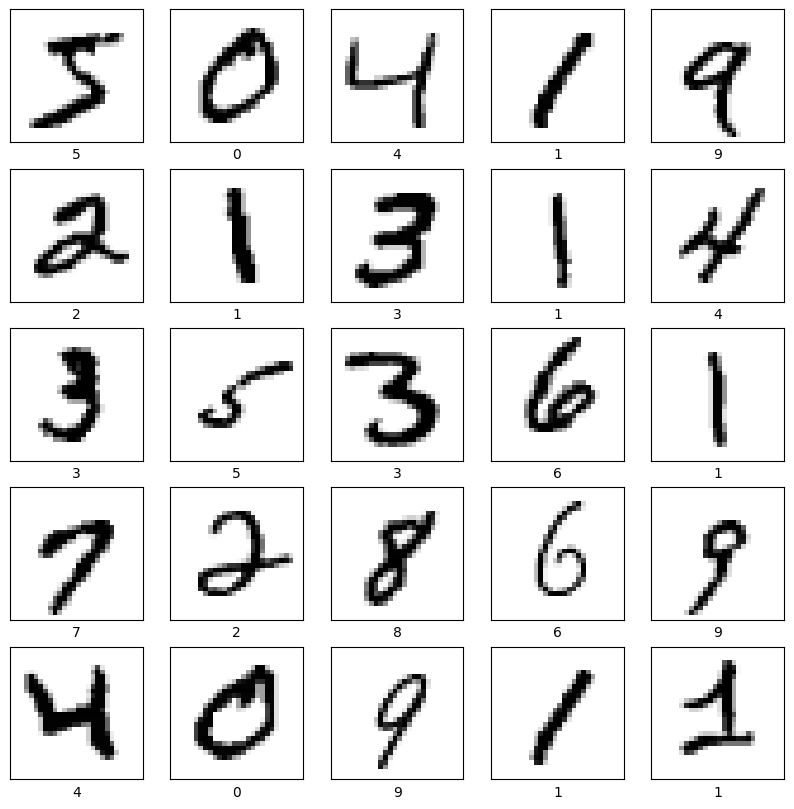

In [12]:
plt.figure(figsize=(10,10))   # Create a new figure (canvas) with size 10x10 inches

for i in range(25):           # Loop 25 times to display the first 25 images

    plt.subplot(5,5,i+1)      # Create a 5x5 grid and select position (i+1) for current image

    plt.xticks([])            # Remove numbers from the x-axis

    plt.yticks([])            # Remove numbers from the y-axis

    plt.grid(False)           # Turn off the grid lines

    plt.imshow(train_digits[i], cmap=plt.cm.binary)  

                               # Display the i-th image using black & white colormap

    plt.xlabel(train_labels[i])  

                               # Show the label (actual digit) below the image

plt.show() 

In [13]:
# Build the model - Method 2
model = models.Sequential()

model.add(layers.Input(shape=(28,28)))

model.add(layers.Flatten())#flatten layer

model.add(layers.Dense(128, activation="relu"))#hidden layer

model.add(layers.Dense(10)) #output layer

In [14]:
# Compile the model

model.compile(optimizer='adam',

              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),

              metrics=['accuracy'])

In [15]:
# Train the model

model.fit(train_digits, train_labels, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 750us/step - accuracy: 0.9234 - loss: 0.2677
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 750us/step - accuracy: 0.9650 - loss: 0.1190
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 746us/step - accuracy: 0.9756 - loss: 0.0807
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 746us/step - accuracy: 0.9818 - loss: 0.0602
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 746us/step - accuracy: 0.9857 - loss: 0.0465
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 750us/step - accuracy: 0.9882 - loss: 0.0374
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 779us/step - accuracy: 0.9911 - loss: 0.0292
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 749us/step - accuracy: 0.9923 - loss: 0.0244
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 746us/step - accuracy: 0.9945 - loss: 0.0186
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 739us/step - accuracy: 0.9954 - loss: 0.0156


In [16]:
# Evaluate the model.

test_loss, test_acc = model.evaluate(test_digits,  test_labels, verbose=2)

print('\nTest accuracy:', test_acc)

313/313 - 0s - 764us/step - accuracy: 0.9778 - loss: 0.0892

Test accuracy: 0.9778000116348267


In [17]:
import keras



In [18]:
# Make predictions

probability_model = keras.Sequential([

    model,                         # The trained model (outputs logits/raw scores)

    keras.layers.Softmax()       # Convert raw scores into probabilities

])

predictions = probability_model.predict(test_digits)  # Predict probabilities for test images

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step


In [19]:
print(predictions[0])

[1.80680473e-07 2.16682361e-09 3.41171216e-07 1.18799726e-04
 1.33497011e-12 2.41413356e-09 7.33433208e-15 9.99524355e-01
 8.66385733e-07 3.55429278e-04]


In [20]:
np.argmax(predictions[0])


np.int64(7)

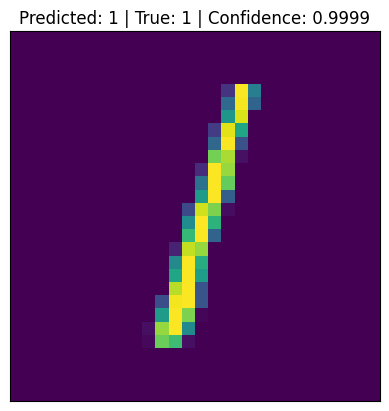

In [21]:
#Verify the predictions

# Choose an image index to test

index = 2



# Display the image

plt.imshow(test_digits[index])

plt.xticks([])

plt.yticks([])



# Get predicted class (highest probability)

predicted_label = np.argmax(predictions[index])



# Get true label

true_label = test_labels[index]



# Get confidence (highest probability value)

confidence = np.max(predictions[index])



# Show title with prediction details

plt.title(f"Predicted: {predicted_label} | True: {true_label} | Confidence: {confidence:.4f}")



plt.show()